In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [180]:
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/Datasets/train_energy_data.csv")
df

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


In [181]:
df.shape

(1000, 7)

In [182]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [184]:
df.describe(include='all')

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
count,1000,1000.000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,3,NaN,NaN,NaN,NaN,2,NaN
top,Residential,NaN,NaN,NaN,NaN,Weekday,NaN
freq,347,NaN,NaN,NaN,NaN,507,NaN
mean,NaN,25462.388,48.372000,25.606000,22.611390,NaN,4166.252570
std,NaN,14294.554,29.061972,14.105166,7.139943,NaN,933.313064
min,NaN,560.000,1.000000,1.000000,10.050000,NaN,1683.950000
25%,NaN,13169.750,22.000000,13.000000,16.475000,NaN,3509.482500
50%,NaN,25477.000,47.000000,26.000000,22.815000,NaN,4175.730000
75%,NaN,37446.250,73.250000,38.000000,28.850000,NaN,4863.850000


In [185]:
df.dtypes

Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
Energy Consumption     float64
dtype: object

In [186]:
df.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [187]:
df.duplicated().sum()

np.int64(0)

In [188]:
df['Day of Week'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [189]:
df['Building Type'].unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [190]:
df1=pd.get_dummies(df[['Building Type','Day of Week']],drop_first=True,dtype=int)
df1

,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,0,1,0
1,0,0,0
2,1,0,1
3,0,1,0
4,0,0,0
...,...,...,...
995,0,1,1
996,1,0,1
997,0,0,0
998,0,1,1


In [191]:
dfe=pd.concat([df,df1],axis=1)
dfe

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,Residential,7063,76,10,29.84,Weekday,2713.95,0,1,0
1,Commercial,44372,66,45,16.72,Weekday,5744.99,0,0,0
2,Industrial,19255,37,17,14.30,Weekend,4101.24,1,0,1
3,Residential,13265,14,41,32.82,Weekday,3009.14,0,1,0
4,Commercial,13375,26,18,11.92,Weekday,3279.17,0,0,0
...,...,...,...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21,0,1,1
996,Industrial,12194,7,22,14.67,Weekend,3546.34,1,0,1
997,Commercial,39562,88,20,32.18,Weekday,5147.21,0,0,0
998,Residential,8348,67,37,16.48,Weekend,3244.98,0,1,1


In [192]:
dfe.drop(['Building Type','Day of Week'],axis=1,inplace=True)
dfe

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,0,1,0
1,44372,66,45,16.72,5744.99,0,0,0
2,19255,37,17,14.30,4101.24,1,0,1
3,13265,14,41,32.82,3009.14,0,1,0
4,13375,26,18,11.92,3279.17,0,0,0
...,...,...,...,...,...,...,...,...
995,14419,68,44,23.95,3661.21,0,1,1
996,12194,7,22,14.67,3546.34,1,0,1
997,39562,88,20,32.18,5147.21,0,0,0
998,8348,67,37,16.48,3244.98,0,1,1


In [193]:
dfe.isna().sum()

Square Footage               0
Number of Occupants          0
Appliances Used              0
Average Temperature          0
Energy Consumption           0
Building Type_Industrial     0
Building Type_Residential    0
Day of Week_Weekend          0
dtype: int64

In [194]:
dfe.dtypes

Square Footage                 int64
Number of Occupants            int64
Appliances Used                int64
Average Temperature          float64
Energy Consumption           float64
Building Type_Industrial       int64
Building Type_Residential      int64
Day of Week_Weekend            int64
dtype: object

In [195]:
df2=dfe['Energy Consumption'].value_counts()
df2

Energy Consumption
2713.95    1
5744.99    1
4101.24    1
3009.14    1
3279.17    1
          ..
3661.21    1
3546.34    1
5147.21    1
3244.98    1
3423.63    1
Name: count, Length: 1000, dtype: int64

In [196]:
x=dfe.drop('Energy Consumption',axis=1)
y=dfe['Energy Consumption']
x

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,0,1,0
1,44372,66,45,16.72,0,0,0
2,19255,37,17,14.30,1,0,1
3,13265,14,41,32.82,0,1,0
4,13375,26,18,11.92,0,0,0
...,...,...,...,...,...,...,...
995,14419,68,44,23.95,0,1,1
996,12194,7,22,14.67,1,0,1
997,39562,88,20,32.18,0,0,0
998,8348,67,37,16.48,0,1,1


In [197]:
x.shape

(1000, 7)

In [198]:
y

0      2713.95
1      5744.99
2      4101.24
3      3009.14
4      3279.17
        ...   
995    3661.21
996    3546.34
997    5147.21
998    3244.98
999    3423.63
Name: Energy Consumption, Length: 1000, dtype: float64

In [199]:
y.shape

(1000,)

In [200]:
dfe

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,0,1,0
1,44372,66,45,16.72,5744.99,0,0,0
2,19255,37,17,14.30,4101.24,1,0,1
3,13265,14,41,32.82,3009.14,0,1,0
4,13375,26,18,11.92,3279.17,0,0,0
...,...,...,...,...,...,...,...,...
995,14419,68,44,23.95,3661.21,0,1,1
996,12194,7,22,14.67,3546.34,1,0,1
997,39562,88,20,32.18,5147.21,0,0,0
998,8348,67,37,16.48,3244.98,0,1,1


<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

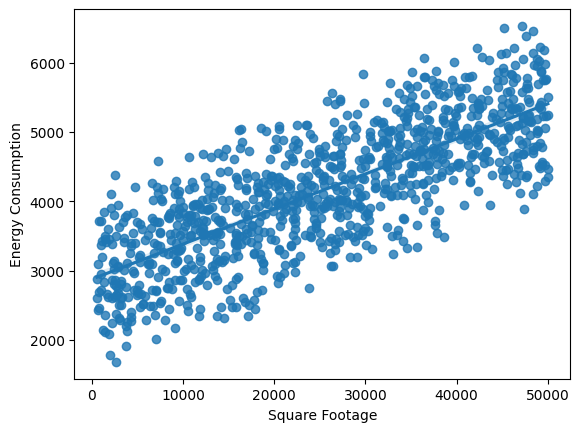

In [201]:
sns.regplot(x='Square Footage',y=y,data=dfe)

<Axes: xlabel='Number of Occupants', ylabel='Energy Consumption'>

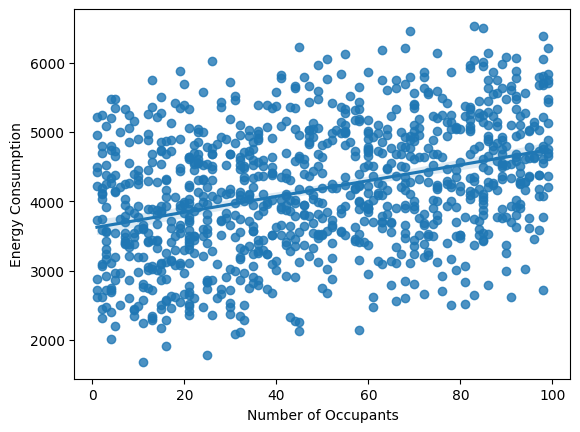

In [202]:
sns.regplot(x='Number of Occupants',y=y,data=dfe)

<Axes: xlabel='Appliances Used', ylabel='Energy Consumption'>

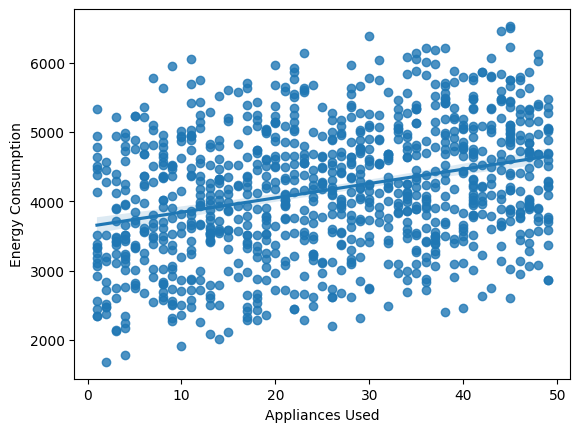

In [203]:
sns.regplot(x='Appliances Used',y=y,data=dfe)

<Axes: xlabel='Average Temperature', ylabel='Energy Consumption'>

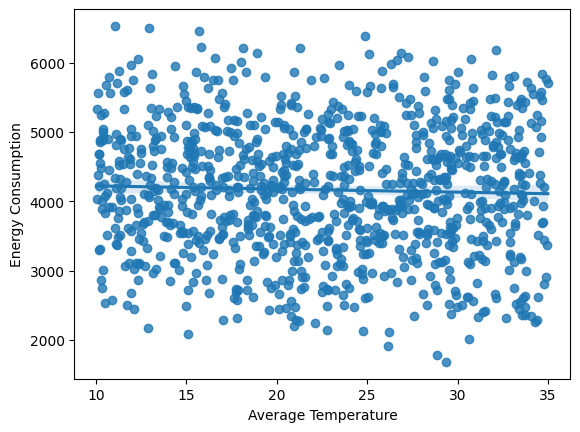

In [204]:
sns.regplot(x='Average Temperature',y=y,data=dfe)

<Axes: xlabel='Building Type_Industrial', ylabel='Energy Consumption'>

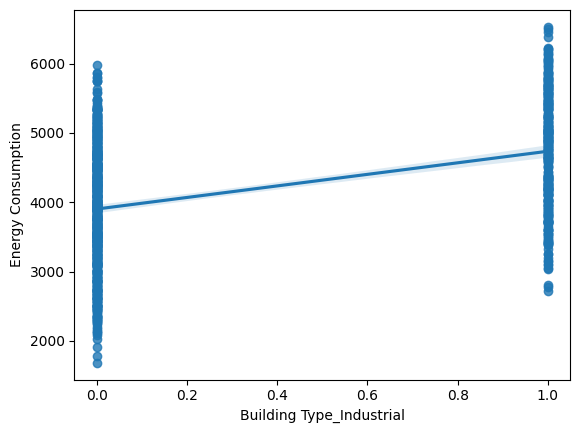

In [205]:
sns.regplot(x='Building Type_Industrial',y=y,data=dfe)

In [206]:
px.scatter(dfe,x='Square Footage',y=y,trendline='ols')

TESTING DATA

In [207]:
td=pd.read_csv("C:/Users/zinan/OneDrive/Documents/Datasets/test_energy_data.csv")
td

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59
...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81
96,Residential,37943,50,23,21.73,Weekend,4248.49
97,Commercial,1558,27,29,16.86,Weekend,2843.60
98,Industrial,2145,56,12,11.77,Weekend,3348.39


In [208]:
td.shape

(100, 7)

In [209]:
td.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [210]:
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [212]:
td.describe(include='all')

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
count,100,100.000000,100.000000,100.000000,100.000000,100,100.00000
unique,3,NaN,NaN,NaN,NaN,2,NaN
top,Residential,NaN,NaN,NaN,NaN,Weekend,NaN
freq,40,NaN,NaN,NaN,NaN,56,NaN
mean,NaN,25881.920000,47.230000,26.970000,22.043300,NaN,4187.57830
std,NaN,13711.075264,29.905526,14.237846,6.957951,NaN,832.55985
min,NaN,1161.000000,2.000000,1.000000,10.400000,NaN,2351.97000
25%,NaN,14161.000000,21.000000,16.750000,15.682500,NaN,3621.92500
50%,NaN,27582.500000,47.000000,27.500000,21.970000,NaN,4249.39000
75%,NaN,38109.500000,73.000000,39.250000,27.492500,NaN,4797.17500


In [213]:
td.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [214]:
td.duplicated().sum()

np.int64(0)

In [215]:
td.dtypes

Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
Energy Consumption     float64
dtype: object

In [216]:
td1=pd.get_dummies(td[['Building Type','Day of Week']],drop_first=True,dtype=int)
td1

,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,0,1,0
1,0,0,1
2,0,0,0
3,0,1,1
4,0,1,0
...,...,...,...
95,0,0,1
96,0,1,1
97,0,0,1
98,1,0,1


In [217]:
tde=pd.concat([td,td1],axis=1)
tde

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,Residential,24563,15,4,28.52,Weekday,2865.57,0,1,0
1,Commercial,27583,56,23,23.07,Weekend,4283.80,0,0,1
2,Commercial,45313,4,44,33.56,Weekday,5067.83,0,0,0
3,Residential,41625,84,17,27.39,Weekend,4624.30,0,1,1
4,Residential,36720,58,47,17.08,Weekday,4820.59,0,1,0
...,...,...,...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81,0,0,1
96,Residential,37943,50,23,21.73,Weekend,4248.49,0,1,1
97,Commercial,1558,27,29,16.86,Weekend,2843.60,0,0,1
98,Industrial,2145,56,12,11.77,Weekend,3348.39,1,0,1


In [218]:
tde.drop(['Building Type','Day of Week'],axis=1,inplace=True)
tde

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,24563,15,4,28.52,2865.57,0,1,0
1,27583,56,23,23.07,4283.80,0,0,1
2,45313,4,44,33.56,5067.83,0,0,0
3,41625,84,17,27.39,4624.30,0,1,1
4,36720,58,47,17.08,4820.59,0,1,0
...,...,...,...,...,...,...,...,...
95,1161,81,11,15.45,3010.81,0,0,1
96,37943,50,23,21.73,4248.49,0,1,1
97,1558,27,29,16.86,2843.60,0,0,1
98,2145,56,12,11.77,3348.39,1,0,1


In [219]:
tde.isna().sum()

Square Footage               0
Number of Occupants          0
Appliances Used              0
Average Temperature          0
Energy Consumption           0
Building Type_Industrial     0
Building Type_Residential    0
Day of Week_Weekend          0
dtype: int64

In [220]:
tde.duplicated().sum()

np.int64(0)

In [221]:
tde.dtypes

Square Footage                 int64
Number of Occupants            int64
Appliances Used                int64
Average Temperature          float64
Energy Consumption           float64
Building Type_Industrial       int64
Building Type_Residential      int64
Day of Week_Weekend            int64
dtype: object

In [222]:
x_test=tde.drop('Energy Consumption',axis=1)
y_test=tde['Energy Consumption']
x_test

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,24563,15,4,28.52,0,1,0
1,27583,56,23,23.07,0,0,1
2,45313,4,44,33.56,0,0,0
3,41625,84,17,27.39,0,1,1
4,36720,58,47,17.08,0,1,0
...,...,...,...,...,...,...,...
95,1161,81,11,15.45,0,0,1
96,37943,50,23,21.73,0,1,1
97,1558,27,29,16.86,0,0,1
98,2145,56,12,11.77,1,0,1


In [223]:
y_test

0     2865.57
1     4283.80
2     5067.83
3     4624.30
4     4820.59
       ...   
95    3010.81
96    4248.49
97    2843.60
98    3348.39
99    4722.59
Name: Energy Consumption, Length: 100, dtype: float64

<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

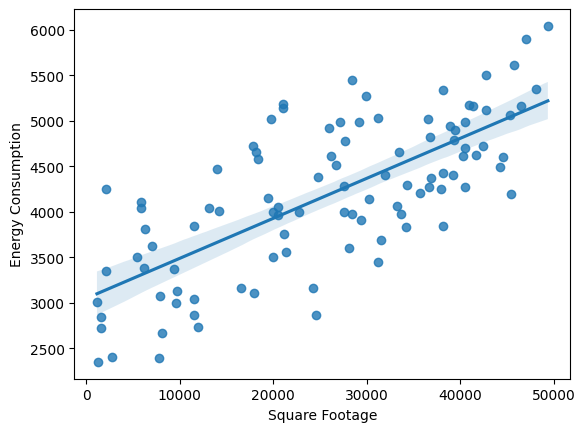

In [224]:
sns.regplot(x='Square Footage',y=y_test,data=tde)

<Axes: xlabel='Number of Occupants', ylabel='Energy Consumption'>

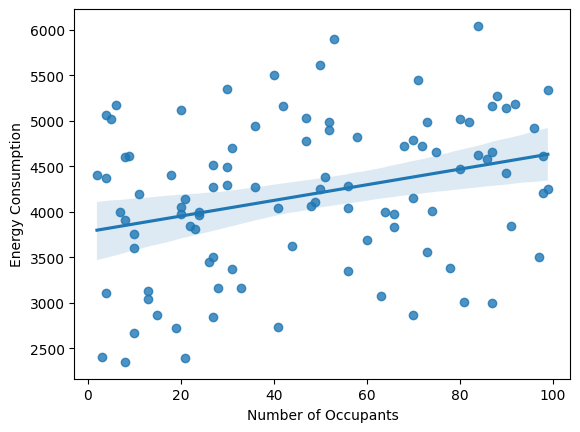

In [225]:
sns.regplot(x='Number of Occupants',y=y_test,data=tde)

In [226]:
tde.corr(numeric_only=True)

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
Square Footage,1.000000,-0.080458,-0.145933,0.030612,0.724039,-0.123083,-0.033246,-0.202413
Number of Occupants,-0.080458,1.000000,0.034320,-0.063608,0.308594,0.001547,-0.004253,0.014976
Appliances Used,-0.145933,0.034320,1.000000,-0.136386,0.176380,-0.140043,0.086742,-0.072980
Average Temperature,0.030612,-0.063608,-0.136386,1.000000,-0.079733,0.039267,0.031012,-0.143007
Energy Consumption,0.724039,0.308594,0.176380,-0.079733,1.000000,0.306376,-0.462059,-0.169386
Building Type_Industrial,-0.123083,0.001547,-0.140043,0.039267,0.306376,1.000000,-0.586033,0.083354
Building Type_Residential,-0.033246,-0.004253,0.086742,0.031012,-0.462059,-0.586033,1.000000,-0.057571
Day of Week_Weekend,-0.202413,0.014976,-0.072980,-0.143007,-0.169386,0.083354,-0.057571,1.000000


<Axes: >

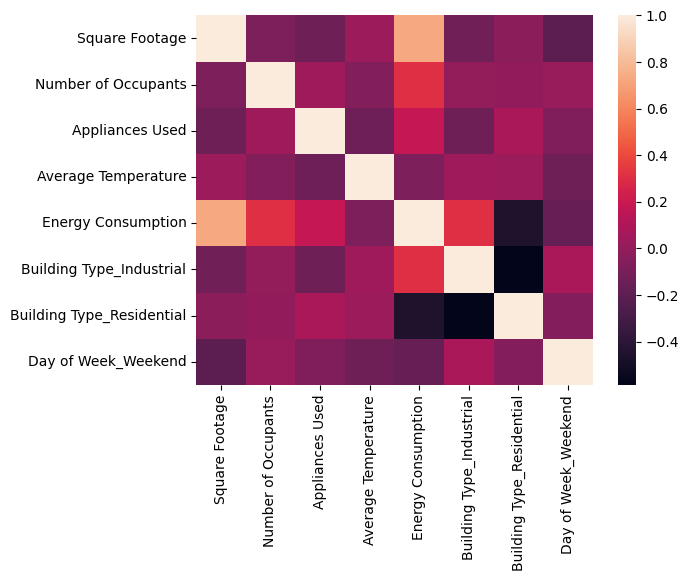

In [227]:
sns.heatmap(tde.corr(numeric_only=True))

In [228]:
px.scatter(tde,x='Square Footage',y=y_test,trendline='ols')

In [229]:
x.shape

(1000, 7)

In [230]:
x_test.shape

(100, 7)

In [231]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x_test)
y_pred

array([2865.54942472, 4283.79956076, 5067.84987388, 4624.29895108,
       4820.60078739, 5026.25085966, 4404.54951202, 2394.35002075,
       3969.09991275, 5136.70172135, 5162.34966309, 3810.10116549,
       4400.49975143, 4991.65068611, 4475.00085639, 2668.05040434,
       4987.50058962, 4040.00055301, 3388.30094445, 4068.94873475,
       4379.84992055, 4921.74986463, 5116.90014513, 4656.30008888,
       5508.65014419, 4205.34961254, 4275.64955752, 4491.94885401,
       3999.14993249, 3758.94956533, 4779.1005936 , 4603.85003053,
       6042.5508037 , 3509.64962804, 3598.84989964, 4003.55000074,
       4193.34934306, 3907.99904306, 2405.35004505, 5611.20040219,
       4789.34969122, 3840.20043095, 4897.65060123, 4428.84925546,
       4276.24992726, 3506.65053648, 5172.75078684, 2731.8496971 ,
       3163.45010316, 4149.10140125, 3160.2491997 , 4294.60009095,
       5275.90096785, 3072.64936946, 3629.60134132, 5014.8000393 ,
       2998.44951019, 4983.44944464, 4707.05052035, 2872.04914

In [232]:
y_test

0     2865.57
1     4283.80
2     5067.83
3     4624.30
4     4820.59
       ...   
95    3010.81
96    4248.49
97    2843.60
98    3348.39
99    4722.59
Name: Energy Consumption, Length: 100, dtype: float64

In [233]:
dg=pd.DataFrame({'actual_value':y_test,'predicted_value':y_pred,'difference':y_test-y_pred})
dg

,actual_value,predicted_value,difference
0,2865.57,2865.549425,0.020575
1,4283.80,4283.799561,0.000439
2,5067.83,5067.849874,-0.019874
3,4624.30,4624.298951,0.001049
4,4820.59,4820.600787,-0.010787
...,...,...,...
95,3010.81,3010.800097,0.009903
96,4248.49,4248.499281,-0.009281
97,2843.60,2843.600224,-0.000224
98,3348.39,3348.400692,-0.010692


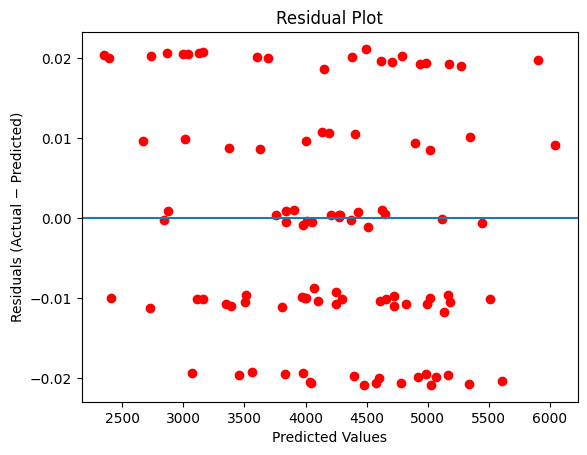

In [238]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color='r')
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residual Plot")
plt.show()




In [235]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
MAPE=mean_absolute_percentage_error(y_test,y_pred)
MAPE

3.0536817882141355e-06

In [236]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)*100
score

99.99999997063026